# **DEMONSTRAÇÃO DE UM PIPELINE SIMPLES DE MACHINE LEARNING**


Neste notebook, vamos percorrer o pipeline de Machine Learning completo, etapa por etapa: preparar os dados, visualizá-los, criar os conjuntos de treino e teste, definir o modelo, treinar, avaliar e, por fim, usar o modelo treinado para fazer uma previsão.

Para executar os comandos, clique no símbolo de executar no canto superior esquerdo da célula. Ele aparece quando você passa o cursor sobre a célula.
Enquanto os comandos da célula estiverem sendo executados, o símbolo de executar permanece com um círculo tracejado movimentando-se ao seu redor.


## 0. Como rodar este notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pasteurjr/notebookvideoaulas/blob/main/01_pipeline_machine_learning/notebook/exalgint3.ipynb)

O curso tem duas partes, com a **mesma estrutura de pastas** (uma pasta por aula):

| O quê | Onde |
|---|---|
| **Código**: os notebooks e os arquivos que eles usam | GitHub: **https://github.com/pasteurjr/notebookvideoaulas** |
| **Dados, vídeos e roteiros** de cada aula | Google Drive: **[pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)** |

**Antes de começar, leia o [README.md da pasta do Google Drive](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)**: ele explica como baixar e organizar os dados de todas as aulas.

**Esta aula (`01_pipeline_machine_learning`) usa:** a base **`bcw.csv`** (câncer de mama, 20 KB), que você carrega pelo botão de upload; não precisa de GPU; nenhuma chave de API.

### Opção A: Google Colab (recomendado)

1. **Baixe o arquivo `bcw.csv`** para o seu computador: ele está nesta pasta do GitHub (`01_pipeline_machine_learning/notebook/bcw.csv`) e na pasta `01_pipeline_machine_learning/notebook` do [Google Drive do curso](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing). Mais adiante, na célula que carrega a base, clique em **Escolher arquivos** e selecione o `bcw.csv`.
2. **Abra este notebook no Colab** pelo botão **Abrir no Colab** acima (ele abre direto do GitHub).
3. **Rode a célula de preparação logo abaixo.** Ela clona o repositório do GitHub para o Colab e instala só as bibliotecas que faltarem.
4. Depois: **Ambiente de execução → Executar tudo**.

**Se aparecer erro de biblioteca** (`ModuleNotFoundError`, `ImportError` ou erro de versão): crie uma célula nova, rode o comando abaixo, depois vá em **Ambiente de execução → Reiniciar sessão** e rode a célula de preparação de novo.

```
!pip install pandas numpy scipy matplotlib scikit-learn
```

### Opção B: no seu computador

Basta baixar. Pré-requisito: [Miniconda](https://docs.conda.io/en/latest/miniconda.html) (ou Anaconda) e Git. No terminal:

```bash
git clone https://github.com/pasteurjr/notebookvideoaulas.git
cd notebookvideoaulas
conda create -n notecursos python=3.12 -y
conda activate notecursos
pip install -r requirements.txt
cd 01_pipeline_machine_learning/notebook
jupyter notebook exalgint3.ipynb
```

**Dados:** o `bcw.csv` já está na pasta; o notebook foi feito para o Colab e usa o botão de upload.

No computador local, a célula de preparação detecta que não está no Colab e não faz nada.

### Dica: peça ajuda a um assistente de IA

Um assistente de programação, como o **Claude Code** ou o **Codex**, faz toda essa preparação sozinho. Abra o assistente numa pasta vazia e peça, por exemplo:

> Clone https://github.com/pasteurjr/notebookvideoaulas. Crie o ambiente conda `notecursos` com Python 3.12 e instale: `pip install -r requirements.txt`. Por fim, abra `01_pipeline_machine_learning/notebook/exalgint3.ipynb` no Jupyter.


In [ ]:
# PREPARAÇÃO DO AMBIENTE NO GOOGLE COLAB (igual em todos os notebooks do curso; no computador local não faz nada)
AULA = "01_pipeline_machine_learning/notebook"                           # pasta desta aula no repositório
USA_DADOS_DO_DRIVE = False                                     # copia os dados da pasta "notebooksvideos" do Drive
PACOTES = {"pandas": "pandas", "numpy": "numpy", "scipy": "scipy", "matplotlib": "matplotlib", "sklearn": "scikit-learn"}   # módulo: pacote pip
SECRETS = []                                   # chaves lidas dos Secrets do Colab (ícone 🔑)

import os, sys, shutil, subprocess, importlib.util

if "google.colab" in sys.modules:
    # 1) Código: clona o repositório do GitHub para o Colab
    if not os.path.exists("/content/notebookvideoaulas"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pasteurjr/notebookvideoaulas.git",
                        "/content/notebookvideoaulas"], check=True)
    os.chdir(f"/content/notebookvideoaulas/{AULA}")

    # 2) Dados: copia da pasta "notebooksvideos" (atalho no Meu Drive) para a pasta da aula
    if USA_DADOS_DO_DRIVE and not os.path.exists("dados"):
        from google.colab import drive
        drive.mount("/content/drive")
        origem = f"/content/drive/MyDrive/notebooksvideos/{AULA}/dados"
        if not os.path.exists(origem):
            raise FileNotFoundError(f"Não encontrei {origem}. Coloque a pasta notebooksvideos do curso no seu Meu Drive "
                                    "(veja o README.md da pasta do Google Drive) e rode esta célula de novo.")
        shutil.copytree(origem, "dados")

    # 3) Bibliotecas: instala só as que a sessão do Colab ainda não tem
    faltando = [pip for modulo, pip in PACOTES.items() if importlib.util.find_spec(modulo) is None]
    if faltando:
        print("Instalando:", ", ".join(faltando))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
        print("Pronto. Se o Colab pedir 'Reiniciar sessão', reinicie e rode esta célula de novo.")
    else:
        print("Todas as bibliotecas já estão instaladas no Colab.")

    # 4) Chaves de API: vêm dos Secrets do Colab (nunca escreva a chave no notebook)
    if SECRETS:
        from google.colab import userdata
        for chave in SECRETS:
            os.environ[chave] = userdata.get(chave)

    print("Pasta da aula:", os.getcwd())
    print("Conteúdo:", sorted(os.listdir(".")))
else:
    print("Ambiente local detectado: usando a pasta atual.")

Inicialmente vamos importar os pacotes Python utilizados no exercício:

**scipy:** Biblioteca para cálculos científicos

**numpy:**-Funções matemáticas para manipulação de matrizes e arrays multidimensionais

**matplotlib:**-Biblioteca para criação de gráficos e visualização de dados

**pandas:**-Biblioteca para manipulação e análise de dados

**sklearn:**(Scikit-learn) Biblioteca principal, possui todos os recursos para Machine Learning


In [16]:
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

Importação de funções usadas no exercício:

In [17]:
import io
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import pandas as pd
import itertools

Importação dos algoritmos de machine learning usados no algoritmo:

In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression


Vamos agora importar uma base de dados pública disponibilizada pela University of California at Irvine - UCI. Trata-se de uma base de dados de
câncer de mama de Wiscosin e está disponível na URL https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data .
Para baixar o arquivo disponibilizado nessa base,acesse o link: https://drive.google.com/file/d/136ctRjJ60k80vJOA5umk8MXAOJp0w8jD/view?usp=sharing

O comando abaixo carrega o arquivo que você acabou de baixar (bcw.csv) para seu computador.  Selecione esse arquivo pressionando o botão "Escolher arquivo", que é exibido após a execução da célula.


In [19]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

# Procura o arquivo que contém 'bcw' no nome entre os arquivos carregados
bcw_filename = None
for filename in uploaded.keys():
    if 'bcw' in filename.lower():
        bcw_filename = filename
        break

if bcw_filename:
    df = pd.read_csv(io.BytesIO(uploaded[bcw_filename]))
    print(f"Arquivo '{bcw_filename}' carregado com sucesso.")
else:
    print("Erro: Arquivo com 'bcw' não encontrado nos arquivos carregados.")

Saving bcw.csv to bcw (5).csv
Arquivo 'bcw (5).csv' carregado com sucesso.


### **Etapa 1 - Preparar dados**

Vamos substituir dados faltantes, excluir uma coluna cujo nome é id e converter os valore das colunas para números reais:




In [20]:

df.replace('?',-99999, inplace=True)
print(df.axes)
df.drop(['id'], axis=1, inplace=True)
print("Dados preparados")


[RangeIndex(start=0, stop=699, step=1), Index(['id', 'clump_thickness', 'size_uniformity', 'shape_uniformity',
       'marginal_adhesion', 'epithelial_size', 'bare_nucleoli',
       'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'],
      dtype='object')]
Dados preparados


### **Etapa 2- Visualizar dados**

Visualizar as colunas (fatores) importadas:

In [21]:
df.columns

Index(['clump_thickness', 'size_uniformity', 'shape_uniformity',
       'marginal_adhesion', 'epithelial_size', 'bare_nucleoli',
       'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'],
      dtype='object')

Visualizar as 10 primeiras linhas da base de dados:

In [22]:
df.head(10)

,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
5,8,10,10,8,7,10,9,7,1,4
6,1,1,1,1,2,10,3,1,1,2
7,2,1,2,1,2,1,3,1,1,2
8,2,1,1,1,2,1,1,1,5,2
9,4,2,1,1,2,1,2,1,1,2


Visuaizar o formato da estrutura dataframe que criamos acima. Ela possui 699 linhas e 10 colunas.

In [23]:

print(df.shape)

(699, 10)


Visualizar alguns dados estatísticos  de cada coluna de nossa base de dados:


In [24]:

print(df.describe())

       clump_thickness  size_uniformity  shape_uniformity  marginal_adhesion  \
count       699.000000       699.000000        699.000000         699.000000   
mean          4.417740         3.134478          3.207439           2.806867   
std           2.815741         3.051459          2.971913           2.855379   
min           1.000000         1.000000          1.000000           1.000000   
25%           2.000000         1.000000          1.000000           1.000000   
50%           4.000000         1.000000          1.000000           1.000000   
75%           6.000000         5.000000          5.000000           4.000000   
max          10.000000        10.000000         10.000000          10.000000   

       epithelial_size  bland_chromatin  normal_nucleoli     mitoses  \
count       699.000000       699.000000       699.000000  699.000000   
mean          3.216023         3.437768         2.866953    1.589413   
std           2.214300         2.438364         3.053634    1.7

Agora vamos plotar um histograma de cada fator:

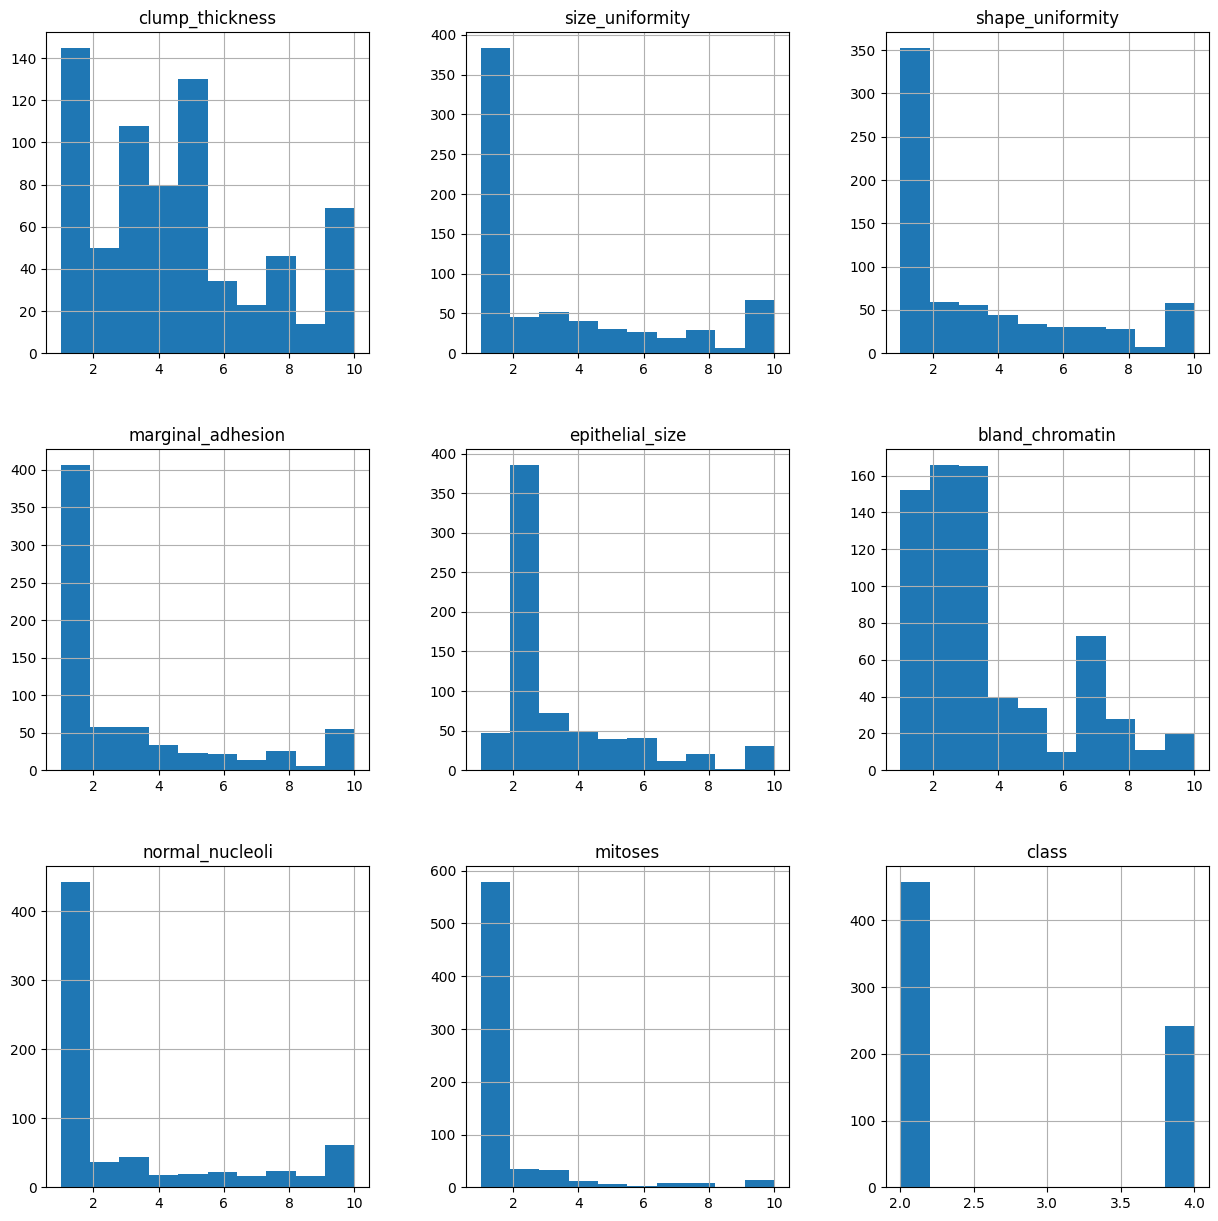

In [25]:

df.hist(figsize = (15, 15))
plt.show()

Vamos plotar a scatter matrix (Matriz de espalhamento):

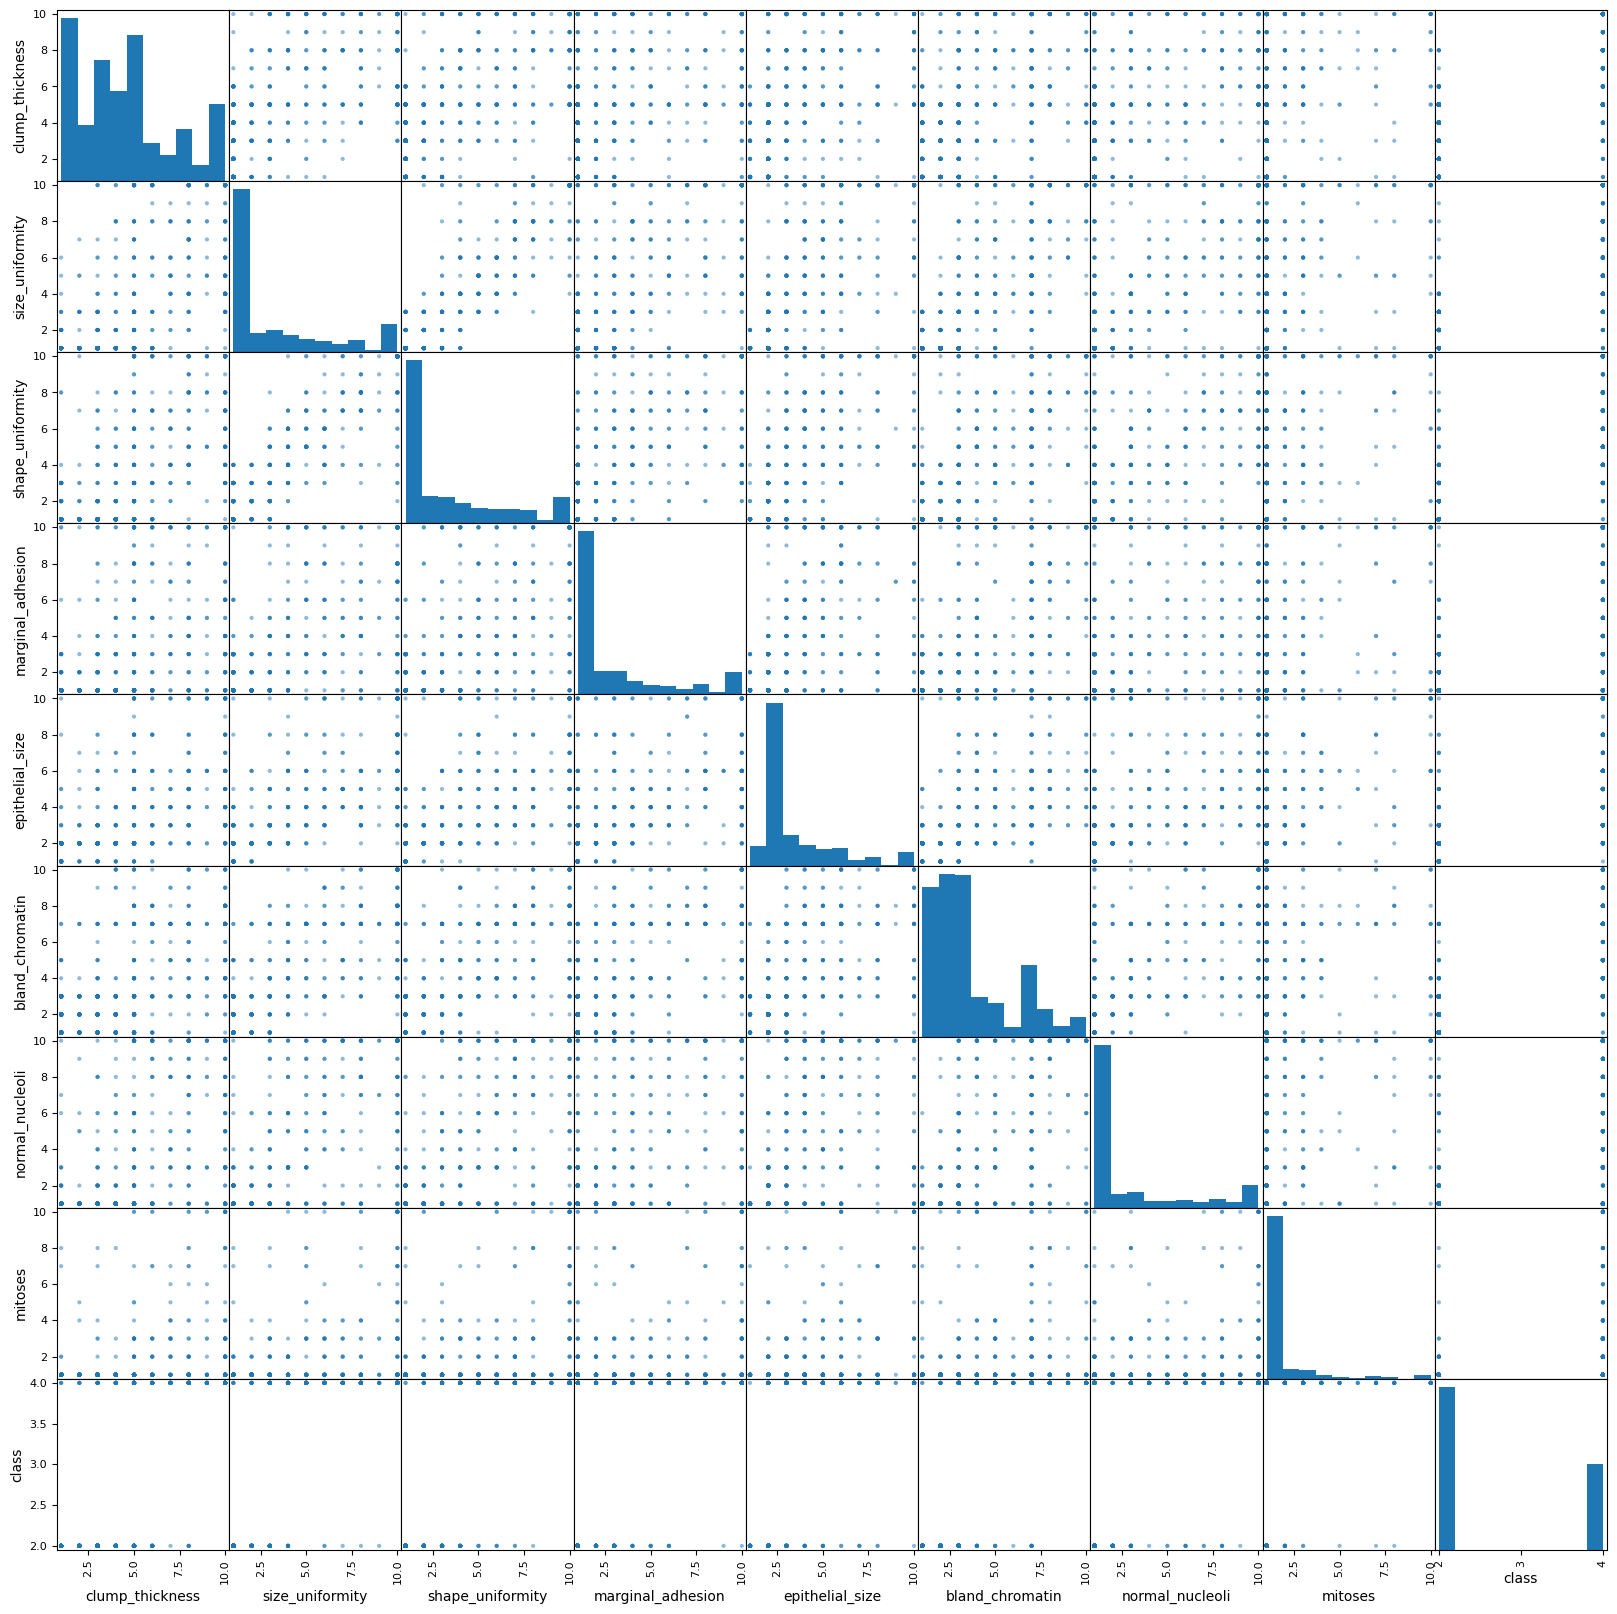

In [26]:

scatter_matrix(df, figsize = (20,20))
plt.show()

### **Etapa 3 - Criar conjuntos**

Inicialmente criamos os conjuntos X (entradas, fatores) e y (saída). O conjunto y está na coluna "class" e possuí os valores 2(benigno) e 4  (maligno):

In [27]:

X = np.array(df.drop(['class'], axis=1))
y = np.array(df['class'])
print("Conjuntos X,y criados")



Conjuntos X,y criados


Agora dividimos os conjuntos de X e y nos conjuntos de treinamento(X_train, y_train) e teste(X_teste,y_teste). O conjunto de teste possui 30% do total dos dados:

In [28]:
testsize = 30.0 #Você pode modificar esse parâmetro para alterar o tamano dos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testsize/100)
print("O conjunto de dados contém {:.0f}".format(X.shape[0])+" elementos")
print("O conjunto de treinamento contém {:.0f}".format(X_train.shape[0])+" elementos")
print("O conjunto de teste contém {:.0f}".format(X_test.shape[0])+" elementos")



O conjunto de dados contém 699 elementos
O conjunto de treinamento contém 489 elementos
O conjunto de teste contém 210 elementos


### **Etapa 4- Definir Modelo**

Criar as instâncias dos modelos que vamos testar: Rede Neural MLP(mlp), Support Vector Machine(svm), Regressão Logística(rl),
RandomForest(rf),árvore de decisão(dt) e K-Neighbors(kn):


In [29]:
profundidaderandomforest = 30
numvizinhoskn = 5
#Abaixo, os modelos a serem usados
kn= ('K-Neighbors', KNeighborsClassifier(n_neighbors = numvizinhoskn))
mlp = ("Rede Neural MLP", MLPClassifier(solver='lbfgs', random_state=0,hidden_layer_sizes=[10, 10]))
rf=("Random Forest", RandomForestClassifier(n_estimators=100,
                          max_depth=profundidaderandomforest,
                          random_state=0))
dt = ("Árvore de Decisão", DecisionTreeClassifier())
rl = ("Regressão logística",LogisticRegression(random_state=0))
svm = ("Support Vector Machine" ,SVC())
print("Modelos instanciados")

Modelos instanciados


Na célula abaixo, defina o modelo a ser treinado. Inicialmente, defimos o K-Neighbors (kn). Modifique o código alocando outros modelos dentre os instanciados acima: Rede Neural MLP(mlp), Regressão Linear(lr), Support Vector Machine(svm), Regressão Logística(rl),RandomForest(rf),árvore de decisão(dt).

In [31]:
modeloasertreinado =kn # Coloque aqui o nome do modelo
nome, modelo = modeloasertreinado
print("Você selecionou o modelo "+ nome+ " para treinamento")

Você selecionou o modelo K-Neighbors para treinamento


Inicializar o modelo escolhido acima utilizando o conjunto de treinamento (X_train, ytrain) e exibir a acurácia obtida sobre o mesmo:

In [32]:


kfold = model_selection.KFold(n_splits=10, random_state = 8, shuffle=True)
cv_results = model_selection.cross_val_score(modelo, X_train, y_train, cv=kfold, scoring='accuracy')


msg = "%s: %f (%f)" % (nome, cv_results.mean(), cv_results.std())
print(msg)

K-Neighbors: 0.973469 (0.018367)


### **Etapa 5 - Efetuar Treinamento**

Efetuar o treinamento sobre o conjunto de treinamento (X_train, ytrain)

In [33]:
modelo.fit(X_train, y_train)

KNeighborsClassifier()

### **Etapa 6 - Avaliar**

Obter a previsões sobre o modelo treinado utilizando os fatores X_test do conjunto de teste

In [34]:
predictions = modelo.predict(X_test)
print("Previsões sobre o conjunto de teste obtidas. Elas são as seguintes:")
print(predictions)


Previsões sobre o conjunto de teste obtidas. Elas são as seguintes:
[2 2 2 2 4 4 4 4 2 4 2 4 2 2 2 4 2 4 4 2 2 4 4 4 2 4 2 2 2 4 4 4 4 2 4 2 4
 2 2 2 2 2 2 2 2 4 2 4 2 2 2 2 4 2 2 2 2 4 4 4 2 2 4 4 2 2 2 2 4 4 2 2 2 2
 2 2 2 4 4 2 2 2 2 2 2 4 2 2 2 2 4 2 2 2 2 4 2 2 4 4 2 2 4 4 4 2 2 2 4 2 2
 4 4 2 2 2 2 2 2 2 2 2 4 4 2 2 2 2 2 4 4 4 4 4 2 2 2 2 2 2 2 2 2 2 2 4 2 2
 4 4 4 2 2 4 2 2 4 2 2 4 2 4 2 2 2 2 4 2 2 2 4 2 2 4 2 2 2 2 2 2 4 2 2 4 2
 4 2 2 2 4 4 2 4 4 2 2 2 2 4 2 2 2 4 2 2 4 2 2 2 2]


Obter as métricas de avaliação:

In [35]:
print("Métricas para o modelo " + nome)
cm = confusion_matrix(y_test,predictions)
TN=cm[0][0]
FN=cm[1][0]
TP=cm[1][1]
FP=cm[0][1]
print("TN={}".format(TN))
print("FN={}".format(FN))
print("TP={}".format(TP))
print("FP={}".format(FP))
precision= float(TP)/float(TP+FP)
recall = float(TP)/float(TP+FN)
print("Precisão={:.4f}".format(float(TP)/float(TP+FP)))
print("Recall={:.4f}".format(float(TP)/float(TP+FN)))
print("Acuracia={:.4f}".format(float(TP+TN)/float(TP+FN+TN+FP)))
print("F-Score={:.4f}".format(2*precision*recall/(precision+ recall)))



Métricas para o modelo K-Neighbors
TN=135
FN=5
TP=67
FP=3
Precisão=0.9571
Recall=0.9306
Acuracia=0.9619
F-Score=0.9437


Plotar a confusion matrix:

Confusion matrix, without normalization
[[135   3]
 [  5  67]]


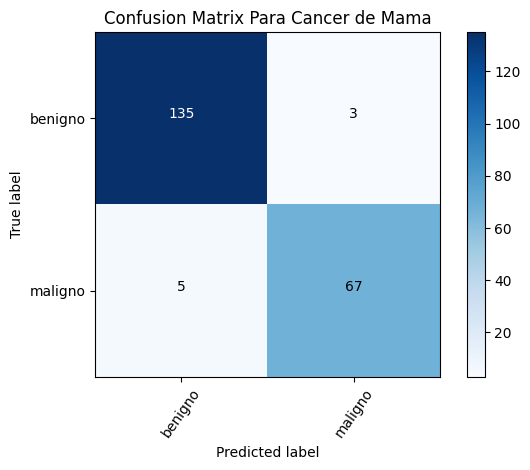

In [36]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=55)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
cm_plot_label =['benigno', 'maligno']
plot_confusion_matrix(cm, cm_plot_label, title ='Confusion Matrix Para Cancer de Mama')


## **Fazendo uma previsão**

Na célula abaixo, insira valores dos fatores de forma que possamos fazer uma previsão. Os valores que estão definidos para eles produzem uma previsão de tumor benigno. Modifique-os com os valores no topo da célula para obter uma previsão de tumor maligno.

In [37]:
#Valores para maligno (insira-os na ordem em que aparecem abaixo): 8.0	10.0	10.0	8.0	7.0	 10.0	9.0	7.0	1.0

clump_thickness = 1.0
uniform_cell_size=1.0
uniform_cell_shape=1.0
marginal_adhesion=1.0
single_epithelial_size=2.0
bare_nuclei=10.0
bland_chromatin=3.0
normal_nucleoli=1.0
mitoses=10.0
print("Fatores atribuídos")

Fatores atribuídos


Agora, execute a célula abaixo para ver o resultado da previsão.

In [38]:

example_measures = np.array([[
  clump_thickness,
  uniform_cell_size,
  uniform_cell_shape,
  marginal_adhesion,
  single_epithelial_size,
  bare_nuclei,
  bland_chromatin,
  normal_nucleoli,
   mitoses]])
example_measures = example_measures.reshape(len(example_measures), -1)
prediction = modelo.predict(example_measures)
if prediction[0]== 2.0:
   print("O tumor é benigno")
else:
   print("O tumor é maligno")

O tumor é benigno


# **Parabéns! Você concluiu o exercício!**